# Kinematic plots for different networks

## Initialisation

In [1]:
import sys
import json
import matplotlib.pyplot as plt
import numpy as np
import argparse
import re

from pathlib import Path
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colorbar import Colorbar
from dataclasses import dataclass

from plot_utils import *

# Get main path of the repository and add it to the path:
try:
    # For scripts
    repo_path = Path(__file__).parent.parent.parent.resolve()
except NameError:
    # For Jupyter notebooks - add the known project root
    repo_path = Path.cwd().parent.parent.resolve()

# Add parent directory to path
sys.path.insert(0, str(repo_path))

# Plot directory:
plot_dir = repo_path / "final_results" / "plots" / "network_comparison"
plot_dir.mkdir(parents=True, exist_ok=True)

from ml_events_utils import stylesheet_default
# from ml_events_utils import color_gio as color_dict
from ml_events_utils import color_deep as color_dict

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.style.use(stylesheet_default)

Observables:

- $\sigma_{\mathrm{tot}}$:     (NN/ POWHEG: `totxsec`,    RFR: ``)
- $p_{T, \, e^{+}}$:            (NN/ POWHEG: `ptep`,       RFR: `ptep`)
- $y_{e^{+}}$:                 (NN/ POWHEG: `yep`,        RFR: `yep`)
- $\cos(\theta^{*}_{e^{+}})$:  (NN/ POWHEG: `cthep`,      RFR: `cthep`)
- $m_{Z}$:                     (NN/ POWHEG: `invmass_Z1`, RFR: `mepem`)
- $\Delta \phi_{ee}$:          (NN/ POWHEG: `dphiee`,     RFR: `dphiee`)  # TODO: Adjust LaTex
- $p_{T, \, Z}$:                  (NN/ POWHEG: `ptee`,       RFR: ``)
- $p_{T, \, 4l}$:              (NN/ POWHEG: `pt4l`,       RFR: `pt4l`)
- $r_{\mathrm{LL}}$:           (NN:         `r_LL`,       RFR: `rll`)

In [2]:
from data_utils import HistogramData


observables = {
    "totxsec": {"Autoencoder": "totxsec",    "FFNN": "totxsec",    "PN": "totxsec",    "POWHEG": "totxsec",    "RFR": None    },
    "ptep":    {"Autoencoder": "ptep",       "FFNN": "ptep",       "PN": "ptep",       "POWHEG": "ptep",       "RFR": "ptep"  },
    "yep":     {"Autoencoder": "yep",        "FFNN": "yep",        "PN": "yep",        "POWHEG": "yep",        "RFR": "yep"   },
    "cthep":   {"Autoencoder": "cthep",      "FFNN": "cthep",      "PN": "cthep",      "POWHEG": "cthep",      "RFR": "cthep" },
    "mepem":   {"Autoencoder": "invmass_Z1", "FFNN": "invmass_Z1", "PN": "invmass_Z1", "POWHEG": "invmass_Z1", "RFR": "mepem" },
    "dphiee":  {"Autoencoder": "dphiee",     "FFNN": "dphiee",     "PN": "dphiee",     "POWHEG": "dphiee",     "RFR": "dphiee"},
    "ptee":    {"Autoencoder": "ptee",       "FFNN": "ptee",       "PN": "ptee",       "POWHEG": "ptee",       "RFR": None    },
    "pt4l":    {"Autoencoder": "pt4l",       "FFNN": "pt4l",       "PN": "pt4l",       "POWHEG": "pt4l",       "RFR": "pt4l"  },
    "rll":     {"Autoencoder": "r_LL",       "FFNN": "r_LL",       "PN": "r_LL",       "POWHEG": "r_LL",       "RFR": "rll"   },
}

# FIXME: Depending on whether we use the direct POWHEG histograms
#        or the ones generated from the labels r_LL data set
#        we can access "r_LL" for POWHEG or not. Adjust accordingly.

print(f"Get observables like this: {observables['totxsec']['FFNN'] = }.")

observables_latex = {
    "totxsec": r"$\sigma_{\mathrm{tot}}$",
    "ptep":    r"$p_{\mathrm{T}, \, e^{+}}$",
    "yep":     r"$y_{e^{+}}$",
    "cthep":   r"$\cos(\theta^{*}_{e^{+}})$",
    "mepem":   r"$m_{e^{+} e^{-}}$",
    "dphiee":  r"$\Delta \phi_{e^{+} e^{-}}$",  # Azimuthal angle difference between e+ e-, coming from one of the Z bosons.
    "ptee":    r"$p_{\mathrm{T}, \, e^{+} e^{-}}$",
    "pt4l":    r"$p_{\mathrm{T}, \, 4l}$",
    "rll":     r"$r_{\mathrm{LL}}$"
}

HistogramData.model_colors = {
    "Autoencoder": color_dict["green"],
    "FFNN":        color_dict["red"],
    "PN":          color_dict["purple"],
    "POWHEG":      color_dict["black"],
    "RFR":         color_dict["blue"],
}

Get observables like this: observables['totxsec']['FFNN'] = 'totxsec'.


## Load the data

1. Put path of the analysis files in dictionary.

In [3]:
autoencoder_path  = repo_path / "final_results" / "autoencoder"
ffnn_path         = repo_path / "final_results" / "ffnn"
pn_path           = repo_path / "final_results" / "pn"
powheg_path       = repo_path / "final_results" / "powheg"
rfr_path          = repo_path / "random_forest_regression"

# Define paths to histogram files and a rescaling factor for each model and order:
# Autoencoder, FFNN, POWHEG are in pb, so we need to rescale it by 1e3 to compare with RFR.
# RFR is in fb.
histogram_paths = {
    "Autoencoder": {
            "LO":    [autoencoder_path / "LO"    / "LL_pred.top", 1e3],
            "LOwS":  [autoencoder_path / "LOwS"  / "LL_pred.top", 1e3],
            "NLO":   [None, 1e3],
            "NLOPS": [autoencoder_path / "NLOPS" / "LL_pred.top", 1e3],
           },
    "FFNN": {
            "LO":    [ffnn_path / "LO"    / "LL_pred.top", 1e3],
            "LOwS":  [ffnn_path / "LOwS"  / "LL_pred.top", 1e3],
            "NLO":   [None, 1e3],
            "NLOPS": [ffnn_path / "NLOPS" / "LL_pred.top", 1e3],
           },
    "PN": {
            "LO":    [pn_path / "LO" / "LL_pred.top", 1e3],
            "LOwS":  [None, 1e3],
            "NLO":   [pn_path / "NLO" / "LL_pred.top", 1e3],
            "NLOPS": [None, 1e3],
           },
    "POWHEG": {
            # "LO":    [powheg_path / "LO"    / "POWHEG_LL.top", 1e3],
            "LO":    [powheg_path / "LO"    / "LL_true.top", 1e3],
            "LOwS":  [powheg_path / "LOwS"  / "LL_true.top", 1e3],
            "NLO":   [None, 1e3],
            "NLOPS": [powheg_path / "NLOPS" / "LL_true.top", 1e3],
           },
    "RFR": {
            "LO":    [rfr_path / "histograms_rfr_ct_lo.top",    1.0],
            "LOwS":  [rfr_path / "histograms_rfr_ct_lows.top",  1.0],
            "NLO":   [rfr_path / "histograms_rfr_ct_nlo.top",   1.0],
            "NLOPS": [rfr_path / "histograms_rfr_ct_nlops.top", 1.0],
           },
}

# Check that files exist:
for model, model_paths in histogram_paths.items():
    for order, (path, _) in model_paths.items():
        if path is not None and not path.exists():
            raise FileNotFoundError(f"File for {model} @ {order} does not exist: {path}")

print(f"Get paths like this: {histogram_paths['RFR']['LO'] = }.")

Get paths like this: histogram_paths['RFR']['LO'] = [PosixPath('/scratch/jlinder/polarisation_tagging/random_forest_regression/histograms_rfr_ct_lo.top'), 1.0].


2. Read in the histograms and align observable names.

In [4]:
from data_utils import read_histogram

model_histograms = {}
for model, model_paths in histogram_paths.items():
    model_histograms[model] = {}
    observable_map_model = {obs_info[model]: obs for obs, obs_info in observables.items()}
    for order, (path, rescaling_factor) in model_paths.items():
        if path is not None:
            print(f"Reading histogram for {model} @ {order} from {path}.")
            model_histograms[model][order] = read_histogram(path, rescaling_factor, observable_map=observable_map_model, model=model, order=order)
            print(f"Available observables for {model} @ {order}: {list(model_histograms[model][order].keys())}")

# test_histogram = read_histogram(histogram_paths["RFR"]["LO"][0], histogram_paths["RFR"]["LO"][1], observable_map=observables, model="RFR")

print(f"Get histograms like this: {model_histograms['RFR']['LO']['ptep'] = }.")
print(f"Access bins like this: {model_histograms['RFR']['LO']['ptep'].bins = }.")
print("Have fun plotting! :)")

Reading histogram for Autoencoder @ LO from /scratch/jlinder/polarisation_tagging/final_results/autoencoder/LO/LL_pred.top.
Available observables for Autoencoder @ LO: ['totxsec', 'mepem', 'ptee', 'r_LL_ptee', 'cthep', 'ptep', 'yep', 'pt4l', 'dphiee', 'rll', 'r_LL_count']
Reading histogram for Autoencoder @ LOwS from /scratch/jlinder/polarisation_tagging/final_results/autoencoder/LOwS/LL_pred.top.
Available observables for Autoencoder @ LOwS: ['totxsec', 'mepem', 'ptee', 'r_LL_ptee', 'cthep', 'ptep', 'yep', 'pt4l', 'dphiee', 'rll', 'r_LL_count']
Reading histogram for Autoencoder @ NLOPS from /scratch/jlinder/polarisation_tagging/final_results/autoencoder/NLOPS/LL_pred.top.
Available observables for Autoencoder @ NLOPS: ['totxsec', 'mepem', 'ptee', 'r_LL_ptee', 'cthep', 'ptep', 'yep', 'pt4l', 'dphiee', 'rll', 'r_LL_count']
Reading histogram for FFNN @ LO from /scratch/jlinder/polarisation_tagging/final_results/ffnn/LO/LL_pred.top.
Available observables for FFNN @ LO: ['totxsec', 'mepem'

## Plotting routine for ordinary kinematic data

In [5]:
def plot_observable_function(histograms: dict,
                             xrange: list,
                             title:str,
                             xlabel:str,
                             unit:str,
                             ylabel1:str,
                             yranges:list=[],
                             logs:list = [False, False],
                             legends:list=[{}, {}],
                             rcParams:dict={},):

    """
    histogram: dict = {
                       "model1": histogram,
                       "model2": histogram,
                      }
    Plots:
        Oben:
        Ratio1:
        Ratio2:
    """

    with plt.style.context(stylesheet_default):
        mpl.rcParams.update(rcParams)
        size = mpl.rcParams['figure.figsize']
        n_plots = 2
        scale_factor = 1.0 + 0.5*(n_plots-1)
        height_ratios = [3,] + [1,]*(n_plots-1)
        fig, axs = plt.subplots(n_plots, 1, sharex=True, figsize=(size[0], scale_factor*size[1]), height_ratios=height_ratios)
        ylabels = ["",] * n_plots

        if len(xrange) == 3:
            width_bins = xrange[2]

            for key, run in histograms.items():
                histograms[key] = run.rebin(width_bins)

        weights_sig = []
        styles = []
        labels = list(histograms.keys())
        for histogram in histograms.values():
            weights_sig.append((histogram.bins, histogram.values, histogram.errors))
            styles.append(histogram.styles)

        plot_histograms(axs[0], weights_sig, labels=labels, styles=styles, uncertainties=False)
        ylabels[0] = ylabel1

        # ratios w.r.t powheg:
        if histograms.get("POWHEG", None):
            ref_histogram = histograms["POWHEG"]
            ref_name = "POWHEG"
        # elif histograms.get("FFNN", None):
        #     ref_histogram = histograms["FFNN"]
        #     ref_name = "FFNN"
        elif histograms.get("RFR", None):
            ref_histogram = histograms["RFR"]
            ref_name = "RFR"
        # elif histograms.get("Autoencoder", None):
        #     ref_histogram = histograms["Autoencoder"]
        #     ref_name = "Autoencoder"
        # elif histograms.get("PN", None):
        #     ref_histogram = histograms["PN"]
        #     ref_name = "PN"
        else:
            ref_histogram = list(histograms.values())[0]
            ref_name = ref_histogram.model

        weights_sig = []
        styles = []
        for i, (model, histogram) in enumerate(histograms.items()):
            if model == "POWHEG":
                continue
            ratio_histogram = histogram / ref_histogram
            weights_sig.append((ratio_histogram.bins, ratio_histogram.values, ratio_histogram.errors))
            styles.append(histogram.styles)

        plot_histograms(axs[1], weights_sig, labels=None, styles=styles, uncertainties=False)
        axs[1].axhline(1.0, color=color_dict['black'], linestyle='--', linewidth=1)

        ylabels[1] = f"X / {ref_name}"

        # axs[0].text(
        #     0.02,
        #     0.98,
        #     "Dashed: LO\nSolid: NLO",
        #     transform=axs[0].transAxes,
        #     va='top',
        #     ha='left',
        #     # bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8, "edgecolor": "gray"},
        # )

        axs[0].set_title(title)
        if unit:
            xlabel  += f" [{unit}]"

        axs[n_plots-1].set_xlabel(xlabel)

        for i, log, yrange, legend in zip(list(range(n_plots)), logs, yranges, legends):
            axs[i].set_ylabel(ylabels[i])
            if log:
                axs[i].set_yscale('log')
            if yrange:
                axs[i].set_ylim(yrange)

            if legend:
                add_legend(axs[i], **legend)
            else:
                add_legend(axs[i], legloc="lower left")

        move_offset_factor(axs[0], ylabels[0])

        return fig, axs

## Plot

Plotting observable ptep @ LO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


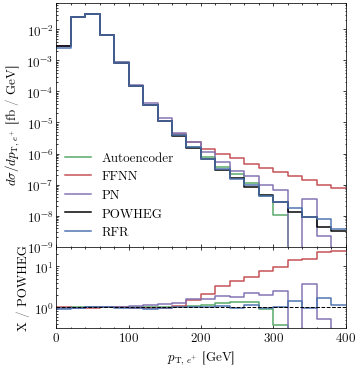

Plotting observable yep @ LO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


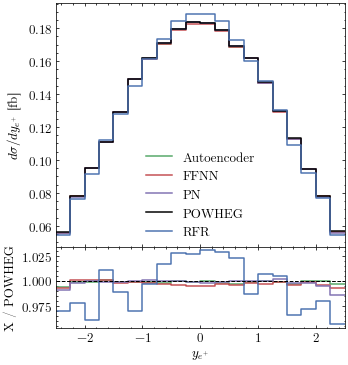

Plotting observable cthep @ LO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


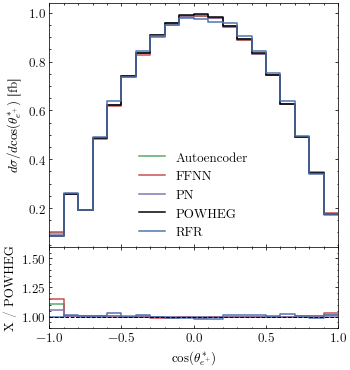

Plotting observable mepem @ LO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


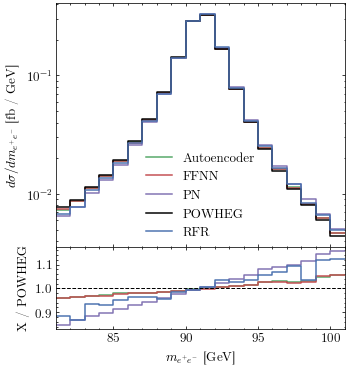

Plotting observable dphiee @ LO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


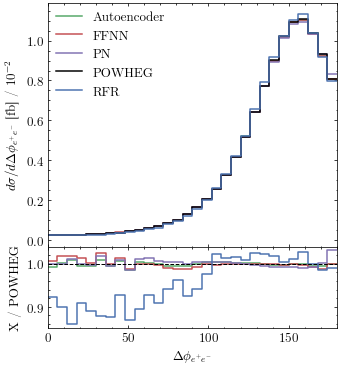

Plotting observable ptee @ LO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


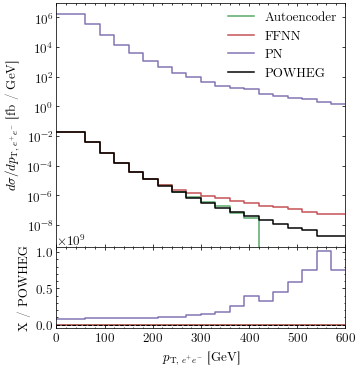

Plotting observable pt4l @ LO.


/scratch/jlinder/polarisation_tagging/final_results/plots/data_utils.py:38: RuntimeWarning: invalid value encountered in divide
  new_values = self.values / other.values
/scratch/jlinder/polarisation_tagging/final_results/plots/data_utils.py:40: RuntimeWarning: invalid value encountered in divide
  new_errors = np.sqrt((self.errors / other.values) ** 2 + (self.values * other.errors / other.values ** 2) ** 2)
/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


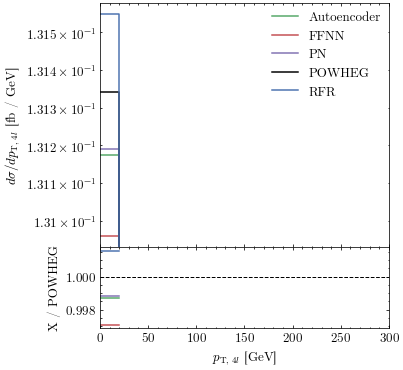

Plotting observable rll @ LO.


/scratch/jlinder/polarisation_tagging/final_results/plots/data_utils.py:38: RuntimeWarning: divide by zero encountered in divide
  new_values = self.values / other.values
/scratch/jlinder/polarisation_tagging/final_results/plots/data_utils.py:40: RuntimeWarning: invalid value encountered in divide
  new_errors = np.sqrt((self.errors / other.values) ** 2 + (self.values * other.errors / other.values ** 2) ** 2)
/scratch/jlinder/polarisation_tagging/final_results/plots/data_utils.py:38: RuntimeWarning: invalid value encountered in divide
  new_values = self.values / other.values
/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


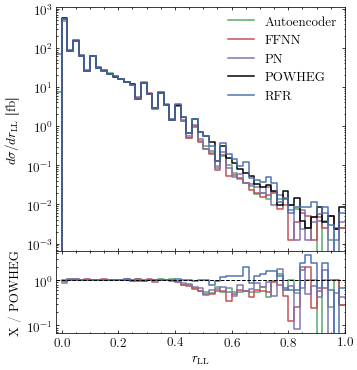

Plotting observable ptep @ LOwS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


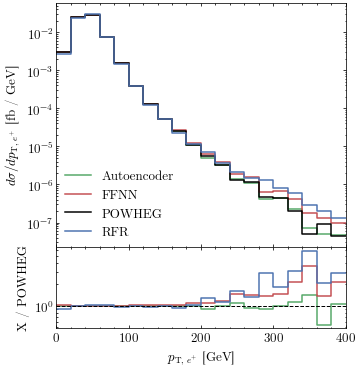

Plotting observable yep @ LOwS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


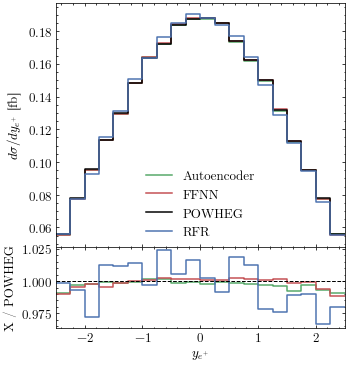

Plotting observable cthep @ LOwS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


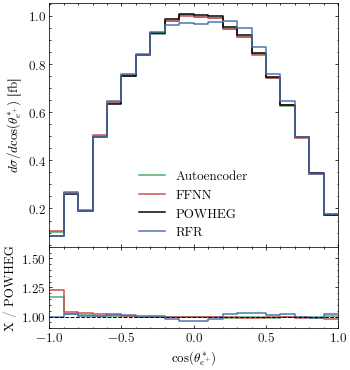

Plotting observable mepem @ LOwS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


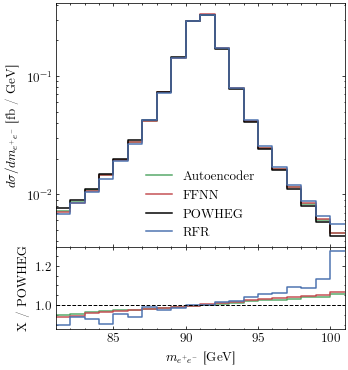

Plotting observable dphiee @ LOwS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


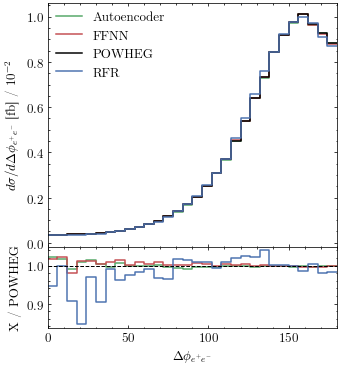

Plotting observable ptee @ LOwS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


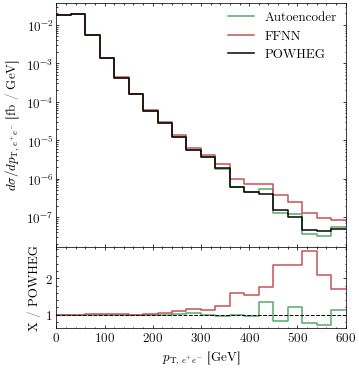

Plotting observable pt4l @ LOwS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


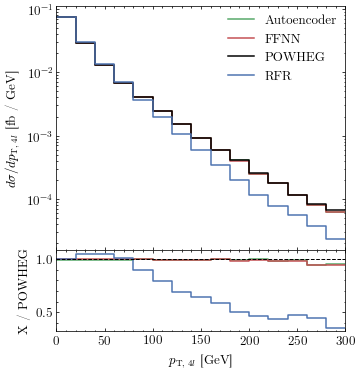

Plotting observable rll @ LOwS.


/scratch/jlinder/polarisation_tagging/final_results/plots/data_utils.py:38: RuntimeWarning: divide by zero encountered in divide
  new_values = self.values / other.values
/scratch/jlinder/polarisation_tagging/final_results/plots/data_utils.py:40: RuntimeWarning: invalid value encountered in divide
  new_errors = np.sqrt((self.errors / other.values) ** 2 + (self.values * other.errors / other.values ** 2) ** 2)
/scratch/jlinder/polarisation_tagging/final_results/plots/data_utils.py:38: RuntimeWarning: invalid value encountered in divide
  new_values = self.values / other.values
/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


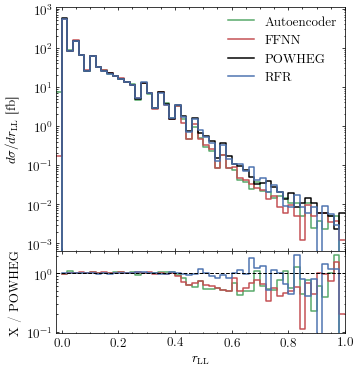

Plotting observable ptep @ NLO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


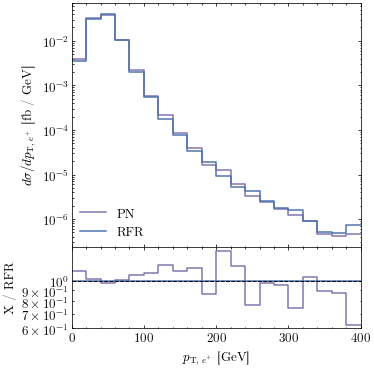

Plotting observable yep @ NLO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


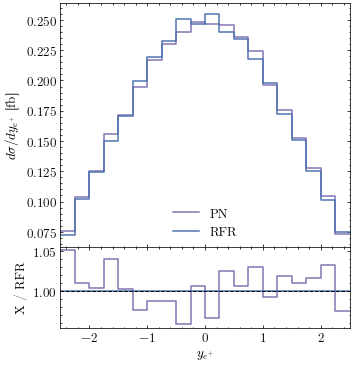

Plotting observable cthep @ NLO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


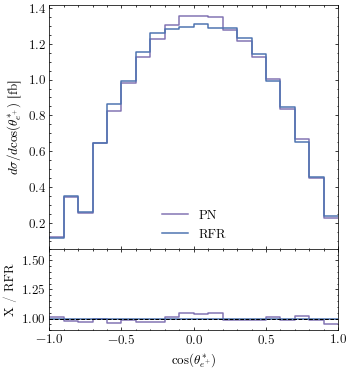

Plotting observable mepem @ NLO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


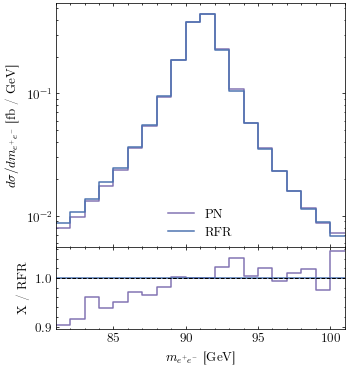

Plotting observable dphiee @ NLO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


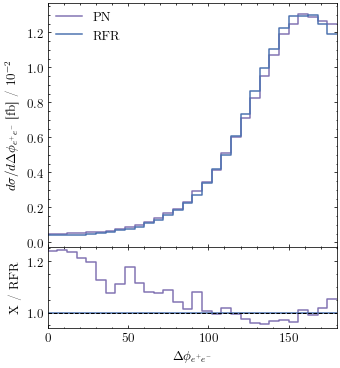

Plotting observable ptee @ NLO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


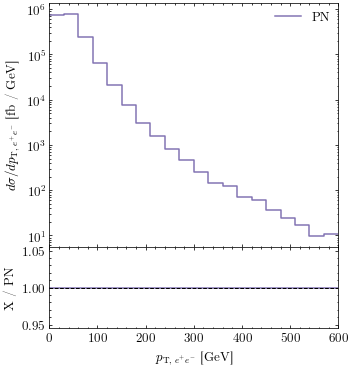

Plotting observable pt4l @ NLO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


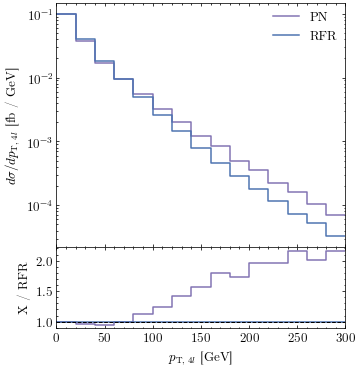

Plotting observable rll @ NLO.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


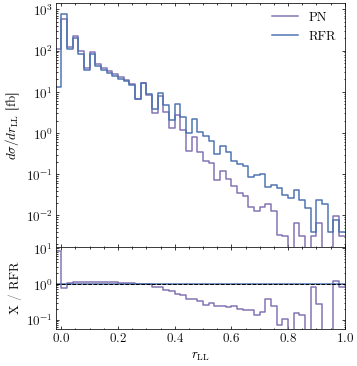

Plotting observable ptep @ NLOPS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


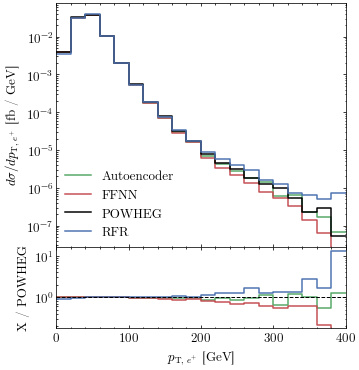

Plotting observable yep @ NLOPS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


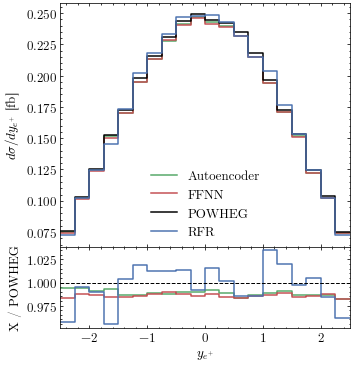

Plotting observable cthep @ NLOPS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


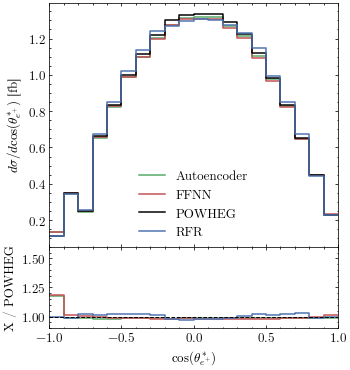

Plotting observable mepem @ NLOPS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


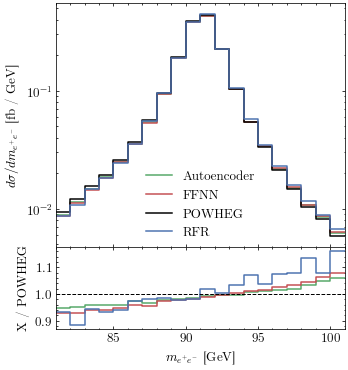

Plotting observable dphiee @ NLOPS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


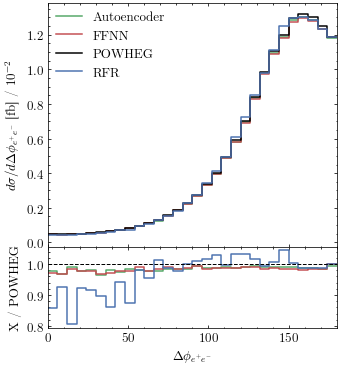

Plotting observable ptee @ NLOPS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


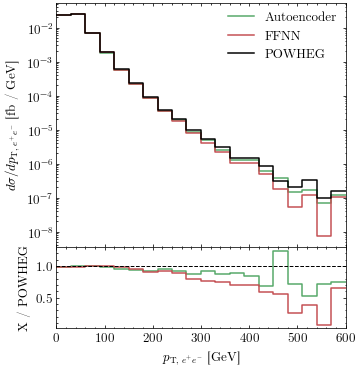

Plotting observable pt4l @ NLOPS.


/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


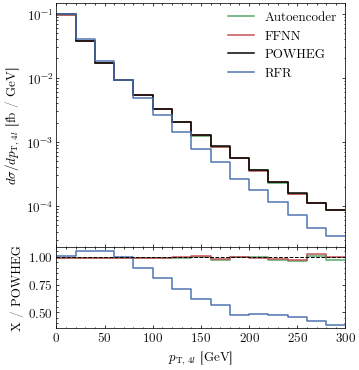

Plotting observable rll @ NLOPS.


/scratch/jlinder/polarisation_tagging/final_results/plots/data_utils.py:38: RuntimeWarning: divide by zero encountered in divide
  new_values = self.values / other.values
/scratch/jlinder/polarisation_tagging/final_results/plots/data_utils.py:40: RuntimeWarning: invalid value encountered in divide
  new_errors = np.sqrt((self.errors / other.values) ** 2 + (self.values * other.errors / other.values ** 2) ** 2)
/scratch/jlinder/polarisation_tagging/final_results/plots/plot_utils.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


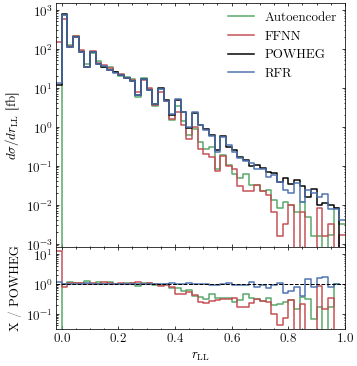

In [6]:
plot_observables = {
    # observables_key: [tex_xlabel, unit, xrange and bin width, [yrange1, yrange2], [log1, log2], [legend1, legend2]]  # default xrange
    "ptep"    : [observables_latex["ptep"],    r"GeV", [  0., 400.,  20.], [[], []], [True,   True], [{"legloc": "lower left"}, {}],   ],  # [  0., 400.,  10.]
    "yep"     : [observables_latex["yep"],     r"",    [-2.5, +2.5,     ], [[], []], [False, False], [{"legloc": "lower center"}, {}], ],  # [-2.5, +2.5, 0.05]
    "cthep"   : [observables_latex["cthep"],   r"",    [ -1.,  +1.,  0.1], [[], [0.9, 1.6]], [False, False], [{"legloc": "lower center"}, {}], ],  # [ -1.,  +1., 0.05]
    "mepem"   : [observables_latex["mepem"],   r"GeV", [ 81., 101.,   1.], [[], []], [True,  False], [{"legloc": "lower center"}, {}], ],  # [ 81., 101.,  0.5]
    "dphiee"  : [observables_latex["dphiee"],  r"",    [  0., 180.,   6.], [[], []], [False, False], [{"legloc": "upper left"}, {}],   ],  # [  0., 180.,   6.]
    "ptee"    : [observables_latex["ptee"],    r"GeV", [  0., 600.,  30.], [[], []], [True,  False], [{"legloc": "upper right"}, {}],  ],  # [  0., 600.,  15.]
    "pt4l"    : [observables_latex["pt4l"],    r"GeV", [  0., 300.,  20.], [[], []], [True,  False], [{"legloc": "upper right"}, {}],  ],  # [  0., 300.,   5.]
    "rll"     : [observables_latex["rll"],     r"",    [-0.02,  1., 0.02], [[], []], [True,   True], [{"legloc": "upper right"}, {}], ],   # [ -0.02,   1., 0.01]
}
# Set rebinned bins explicitly as list in order to avoid rounding issues.
for key in plot_observables.keys():
    if len(plot_observables[key][2]) == 3:
        plot_observables[key][2][2] = np.arange(plot_observables[key][2][0], plot_observables[key][2][1] + plot_observables[key][2][2], plot_observables[key][2][2])


metadata = {'Title': "Kinematic distributions for different models",
            'Author': 'Jakob Linder',
            'CreationDate': datetime.today(),
            'ModDate': datetime.today(),
            'Creator': 'Python'}

fp_rcParams = {}

for order in ["LO", "LOwS", "NLO", "NLOPS"]:
# for order in ["LO", "NLO"]:
    file = plot_dir / Path(f"network_comparison_{order.lower()}.pdf")
    metadata['Title'] = f"Kinematic distributions for different models @ {order}"
    with PdfPages(filename=file, metadata=metadata) as pdf:
        for fp_observable, (fp_xlabel, fp_unit, fp_xrange, fp_yranges, fp_logs, fp_legends) in plot_observables.items():
            print(f"Plotting observable {fp_observable} @ {order}.")

            histograms = get_histograms_for_observable(model_histograms, fp_observable, order)

            fp_title  = f""
            fp_ylabel1 = r"$d \sigma / d " + fp_xlabel[1:-1] + r"$ [fb]"
            if fp_unit:
                fp_ylabel1 = fp_ylabel1[:-1] + f" / {fp_unit}]"


            fig, axs = plot_observable_function(histograms,
                                                xrange=fp_xrange,
                                                title=fp_title,
                                                xlabel=fp_xlabel,
                                                unit=fp_unit,
                                                ylabel1=fp_ylabel1,
                                                yranges=fp_yranges,
                                                logs=fp_logs,
                                                legends=fp_legends,
                                                rcParams=fp_rcParams)

            pdf.savefig(fig)
            plt.show()

